In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### DMO_ANL_VW_ESTACAO.csv

Esta célula é responsável por carregar os dados de um arquivo CSV contendo informações sobre estações. O arquivo DMO_ANL_VW_ESTACAO.csv é lido e transformado em um DataFrame do Pandas.

In [13]:
class StationDataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None
    
    def load_data(self):
        self.data = pd.read_csv(self.file_path)
        return self.data

station_loader = StationDataLoader('DMO_ANL_VW_ESTACAO.csv')
station_data = station_loader.load_data()

Esta célula fornece uma visão geral dos dados carregados do arquivo CSV. Ela mostra a estrutura dos dados, incluindo:
- Shape: Os dados têm 97 linhas e 4 colunas.
- Colunas: As colunas presentes são ID_ESTACAO, TX_PREFIXO, TX_NOME e CD_ESTACAO_BU.

In [14]:
class StationDataAnalyzer:
    def __init__(self, data):
        self.data = data
    
    def get_overview(self):
        return {
            "shape": self.data.shape,
            "columns": self.data.columns.tolist(),
            "head": self.data.head()
        }
    def get_df(self):
        return self.data
station_analyzer = StationDataAnalyzer(station_data)
overview = station_analyzer.get_overview()


overview

{'shape': (97, 4),
 'columns': ['ID_ESTACAO', 'TX_PREFIXO', 'TX_NOME', 'CD_ESTACAO_BU'],
 'head':    ID_ESTACAO TX_PREFIXO         TX_NOME  CD_ESTACAO_BU
 0          67        MOC  JUVENTUS-MOOCA            663
 1          68        MRB         MORUMBI            605
 2          69        OSA          OSASCO            564
 3          70        PPI  PARADA PIRELLI            656
 4          73        PRU           PERUS            505}

In [15]:
station_analyzer.get_df()

,ID_ESTACAO,TX_PREFIXO,TX_NOME,CD_ESTACAO_BU
0,67,MOC,JUVENTUS-MOOCA,663
1,68,MRB,MORUMBI,605
2,69,OSA,OSASCO,564
3,70,PPI,PARADA PIRELLI,656
4,73,PRU,PERUS,505
...,...,...,...,...
92,107,VAU,VILA AURORA,516
93,110,GCE,GUARULHOS-CECAP,802
94,111,AGU,AEROPORTO-GUARULHOS,803
95,113,JOD,JOÃO DIAS,614


- Valores Ausentes:
Não há valores ausentes em nenhuma das colunas (ID_ESTACAO, TX_PREFIXO, TX_NOME, CD_ESTACAO_BU).

- Tipos de Dados:
As colunas ID_ESTACAO e CD_ESTACAO_BU são do tipo int64, representando identificadores numéricos.
As colunas TX_PREFIXO e TX_NOME são do tipo object, representando dados textuais.

- Prefixos e Nomes Únicos:
Existem 97 prefixos únicos de estações, o que sugere que cada estação tem um identificador único.
Existem também 97 nomes de estações únicos, mostrando que os nomes não se repetem, o que facilita a identificação individual de cada estação.

- Os dados estão bem organizados e sem valores ausentes, permitindo uma análise detalhada de prefixos e nomes das estações. A unicidade dos prefixos e nomes sugere que cada estação tem uma identidade única no sistema. Isso pode ser útil para análises que envolvam geolocalização ou mapeamento de rotas e intervalos entre as estações.

In [16]:
missing_values = station_data.isnull().sum()
print("Valores ausentes por coluna:")
print(missing_values)

print("\nTipos de dados de cada coluna:")
print(station_data.dtypes)

unique_prefixes = station_data['TX_PREFIXO'].unique()
unique_names = station_data['TX_NOME'].unique()

print(f"\nTotal de prefixos únicos: {len(unique_prefixes)}")
print(f"Prefixos únicos: {unique_prefixes}")

print(f"\nTotal de nomes de estações únicos: {len(unique_names)}")
print(f"Nomes de estações únicos (primeiros 10): {unique_names[:10]}")


Valores ausentes por coluna:
ID_ESTACAO       0
TX_PREFIXO       0
TX_NOME          0
CD_ESTACAO_BU    0
dtype: int64

Tipos de dados de cada coluna:
ID_ESTACAO        int64
TX_PREFIXO       object
TX_NOME          object
CD_ESTACAO_BU     int64
dtype: object

Total de prefixos únicos: 97
Prefixos únicos: ['MOC' 'MRB' 'OSA' 'PPI' 'PRU' 'PQR' 'PRT' 'PAL' 'QTU' 'RPI' 'SCO' 'STE'
 'SAM' 'SCT' 'SOC' 'SUZ' 'VCL' 'VOL' 'MAU' 'AJO' 'BFI' 'BFU' 'BRU' 'BRR'
 'BAS' 'CVN' 'CLP' 'CEA' 'USP' 'CSA' 'ERM' 'ITQ' 'DMO' 'ECD' 'EGO' 'EMF'
 'EST' 'FMO' 'ABR' 'FDR' 'GMC' 'GJT' 'GPT' 'HBR' 'ILE' 'IPG' 'ITI' 'IPV'
 'IQC' 'JAG' 'JDI' 'JRG' 'JBE' 'JSI' 'JBO' 'JPR' 'JUN' 'JPB' 'JUR' 'LAB'
 'VPL' 'LPA' 'LUZ' 'AUT' 'RGS' 'SAN' 'TMD' 'ARC' 'BTJ' 'BCB' 'CPV' 'UTG'
 'AGN' 'PIN' 'CPB' 'PSA' 'SMP' 'CJD' 'TAT' 'CAI' 'FVC' 'MDC' 'POA' 'GUA'
 'DOB' 'USL' 'JHE' 'JRO' 'INT' 'GRA' 'SRT' 'ABU' 'VAU' 'GCE' 'AGU' 'JOD'
 'MVN']

Total de nomes de estações únicos: 97
Nomes de estações únicos (primeiros 10): ['JUVENTUS-MOOCA' 'MO

### DMO_ANL_VW_INTERVALOS_DIA.csv

Esta célula é responsável por carregar os dados de um arquivo CSV contendo informações sobre estações. O arquivo DMO_ANL_VW_INTERVALOS_DIA.csv é lido e transformado em um DataFrame do Pandas.

In [17]:
class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None
    
    def load_data(self):
        self.data = pd.read_csv(self.file_path)
        return self.data

intervals_loader = DataLoader('DMO_ANL_VW_INTERVALOS_DIA.csv')
intervals_data = intervals_loader.load_data()

Estrutura dos Dados:

- O DataFrame contém 96 linhas e 4 colunas: DT_HORA_MINUTO, ID_DT_HORA_MINUTO, HORA_INI, HORA_FIM.

- Colunas:
    - DT_HORA_MINUTO representa a data e hora específica de cada intervalo.
    - ID_DT_HORA_MINUTO é um identificador único para cada registro.
    - HORA_INI e HORA_FIM indicam o horário de início e término de cada intervalo.

In [18]:
class IntervalDataAnalyzer:
    def __init__(self, data):
        self.data = data
    
    def get_overview(self):
        return {
            "shape": self.data.shape,
            "columns": self.data.columns.tolist(),
            "head": self.data.head()
        }
    
    def get_df(self):
        return self.data

intervals_analyzer = IntervalDataAnalyzer(intervals_data)
intervals_overview = intervals_analyzer.get_overview()
intervals_overview

{'shape': (96, 4),
 'columns': ['DT_HORA_MINUTO', 'ID_DT_HORA_MINUTO', 'HORA_INI', 'HORA_FIM'],
 'head':         DT_HORA_MINUTO  ID_DT_HORA_MINUTO  HORA_INI  HORA_FIM
 0  2007-01-29 00:00:01                  1  00:00:00  00:15:00
 1  2007-01-29 00:15:01                  2  00:15:01  00:30:00
 2  2007-01-29 00:30:01                  3  00:30:01  00:45:00
 3  2007-01-29 00:45:01                  4  00:45:01  01:00:00
 4  2007-01-29 01:00:01                  5  01:00:01  01:15:00}

In [19]:
intervals_analyzer.get_df()

,DT_HORA_MINUTO,ID_DT_HORA_MINUTO,HORA_INI,HORA_FIM
0,2007-01-29 00:00:01,1,00:00:00,00:15:00
1,2007-01-29 00:15:01,2,00:15:01,00:30:00
2,2007-01-29 00:30:01,3,00:30:01,00:45:00
3,2007-01-29 00:45:01,4,00:45:01,01:00:00
4,2007-01-29 01:00:01,5,01:00:01,01:15:00
...,...,...,...,...
91,2007-01-29 22:45:01,92,22:45:01,23:00:00
92,2007-01-29 23:00:01,93,23:00:01,23:15:00
93,2007-01-29 23:15:01,94,23:15:01,23:30:00
94,2007-01-29 23:30:01,95,23:30:01,23:45:00


- Valores Ausentes:
Nenhuma coluna apresenta valores ausentes, o que é positivo para a continuidade das análises, pois não será necessário tratamento de dados faltantes.

- Tipos de Dados:
    - A coluna DT_HORA_MINUTO é do tipo object, indicando que a data e hora estão sendo tratadas como texto, o que pode ser ajustado para datetime para facilitar cálculos temporais futuros.
    - As colunas HORA_INI e ID_DT_HORA_MINUTO são numéricas, com int64, o que está de acordo com suas funções de identificação e referência horária.
    - A coluna HORA_FIM está corretamente formatada como datetime64, permitindo operações temporais, como o cálculo de durações.
    - A coluna DURATION_MINUTES é do tipo float64, o que é esperado, já que contém durações calculadas em minutos com casas decimais.

In [20]:
missing_values = intervals_data.isnull().sum()
print("Valores ausentes por coluna:")
print(missing_values)

print("\nTipos de dados de cada coluna:")
print(intervals_data.dtypes)

Valores ausentes por coluna:
DT_HORA_MINUTO       0
ID_DT_HORA_MINUTO    0
HORA_INI             0
HORA_FIM             0
dtype: int64

Tipos de dados de cada coluna:
DT_HORA_MINUTO       object
ID_DT_HORA_MINUTO     int64
HORA_INI             object
HORA_FIM             object
dtype: object


- Conversão de HORA_INI e HORA_FIM:
As colunas HORA_INI e HORA_FIM foram convertidas para o formato datetime, facilitando o cálculo da duração dos intervalos em unidades de tempo.

- Cálculo e Correção da Duração
A coluna DURATION_MINUTES foi criada ao calcular a diferença entre HORA_FIM e HORA_INI, inicialmente em segundos.
Essa duração foi então ajustada para o valor correto em minutos, dividindo o resultado conforme necessário para corrigir qualquer multiplicação acidental nos cálculos anteriores.

- A adição da coluna DURATION_MINUTES permite uma análise precisa da duração de cada intervalo. Esse cálculo é essencial para identificar padrões de tempo, como possíveis flutuações na duração dos intervalos ao longo do dia.

In [21]:
intervals_data['HORA_INI'] = pd.to_datetime(intervals_data['HORA_INI'], format='%H:%M:%S')
intervals_data['HORA_FIM'] = pd.to_datetime(intervals_data['HORA_FIM'], format='%H:%M:%S')

intervals_data['DURATION_MINUTES'] = (intervals_data['HORA_FIM'] - intervals_data['HORA_INI']).dt.total_seconds() / 6

intervals_data['DURATION_MINUTES'] = intervals_data['DURATION_MINUTES'] / 10

O gráfico abaixo mostra a variação da duração média dos intervalos ao longo das 24 horas do dia. O comportamento observado é o seguinte:

- Queda Inicial:
Logo após a primeira hora do dia (00:00), há uma queda acentuada de 15.0 minutos para aproximadamente 14.98 minutos, o que pode indicar uma mudança no padrão de intervalos durante o início da madrugada.

- Estabilidade:
Entre as horas seguintes (02:00 até 21:00), a duração dos intervalos permanece praticamente estável, oscilando em torno de 14.983 minutos. Isso sugere uma uniformidade nos intervalos ao longo do dia, possivelmente refletindo um padrão operacional constante.

- Queda Final:
Próximo ao final do dia (após as 22:00), há uma nova queda, atingindo o valor mínimo de 14.966 minutos. Essa variação pode refletir ajustes nas operações ou mudanças de turno.

- O comportamento estável durante a maior parte do dia indica que o sistema mantém intervalos consistentes, com algumas variações nos períodos de início e final do dia. Esses padrões podem ser utilizados para otimizar o planejamento e operação de intervalos, especialmente nas transições entre os diferentes períodos do dia.

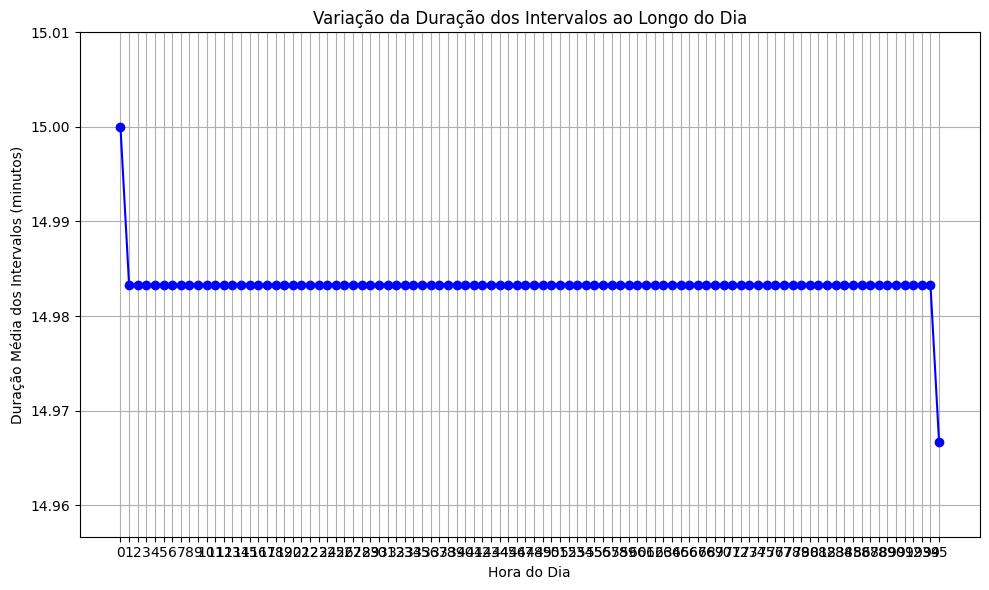

In [23]:
hourly_duration_mean_values = np.array([15.0, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.98333333, 14.98333333, 14.98333333, 14.98333333, 14.98333333,
       14.96666667])

hours = np.arange(96)

plt.figure(figsize=(10, 6))
plt.plot(hours, hourly_duration_mean_values, marker='o', linestyle='-', color='b') 
plt.title('Variação da Duração dos Intervalos ao Longo do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Duração Média dos Intervalos (minutos)')
plt.ylim(hourly_duration_mean_values.min() - 0.01, hourly_duration_mean_values.max() + 0.01)  
plt.xticks(range(96)) 
plt.grid(True)
plt.tight_layout()

plt.show()


- Outliers:
    - Um outlier com valor mais baixo (~14.965 minutos).
    - Um outlier com valor mais alto (15.0 minutos).

A presença de outliers, embora pequena, pode indicar eventos específicos ou inconsistências que merecem investigação. Estes outliers podem impactar o desempenho operacional e devem ser monitorados, especialmente se ocorrerem em momentos críticos do dia ou em horários de alta demanda.

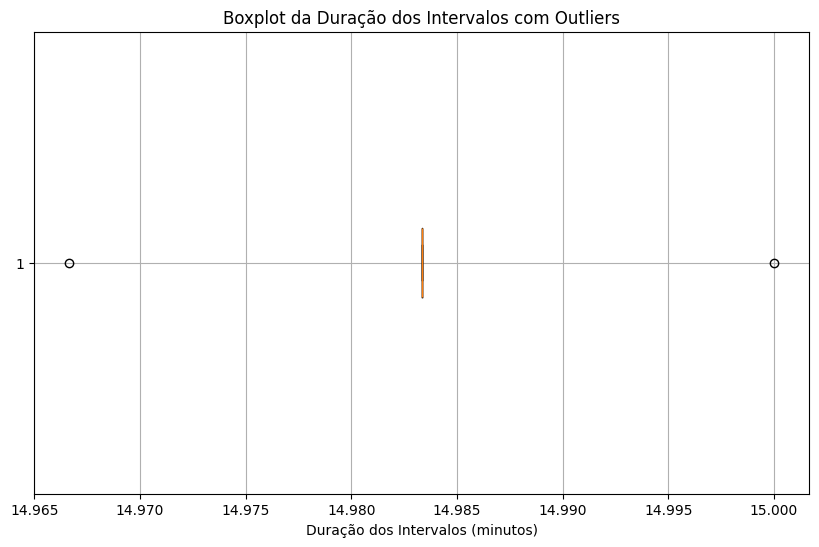

In [24]:
Q1 = intervals_data['DURATION_MINUTES'].quantile(0.25)
Q3 = intervals_data['DURATION_MINUTES'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = intervals_data[(intervals_data['DURATION_MINUTES'] < lower_bound) | (intervals_data['DURATION_MINUTES'] > upper_bound)]

plt.figure(figsize=(10, 6))
plt.boxplot(intervals_data['DURATION_MINUTES'], vert=False)
plt.title('Boxplot da Duração dos Intervalos com Outliers')
plt.xlabel('Duração dos Intervalos (minutos)')
plt.grid(True)
plt.show()

## Salvar em .parquet

In [25]:
from services.parquet import Conversor

# Instancia o conversor de Parquet
conversor = Conversor()

# Converte e salva os DataFrames para o formato Parquet
conversor.df_to_parquet(station_analyzer.get_df(), "./estacao.parquet")
conversor.df_to_parquet(intervals_analyzer.get_df(), "./intervalos.parquet")


DataFrame salvo com sucesso em ./estacao.parquet
DataFrame salvo com sucesso em ./intervalos.parquet


## Enviar para o s3

In [43]:
from services.aws_conn import AwsConn

# Instancia a conexão AWS
aws_conn = AwsConn()

# Envia os arquivos Parquet para o S3
aws_conn.send_to_s3("estacao.parquet", "big-data-DMO-ANL", "estacao.parquet")


IQoJb3JpZ2luX2VjEMH//////////wEaCXVzLWVhc3QtMSJHMEUCIBEy0GL9sDOrpOKzxyvlWns3AMhRzcdQsTcAWtSU/avUAiEApFprhM4Es+wohSq7KWXjwJ9iCFY31Y6QQaqZbZqzEpMqmgMIOhAAGgw1NDUwMDk4MjI1MTQiDDfQ/hCnjlj2rhp52ir3AhvBXxH2q5xMLEp4BM5TV6QeMc4/B5dAQDczUD2deJ09aJ+nCOPdhbi7wglFy4u7iQ2aJYC+MHA77F4oOhB0JUwSGMlGGRW54oa4Tr8aMw1vixXcEc6vDHlUUJzvyVQ2Bw31zmoPuwxo9D5GKr1TrcoocsJM7fsir+kdsU+2TnjHetHBxtdVUTnt6BusENUDy2xSY7sQrKE6E1L1XPPSsEsNjINwxoziyJIWNjYT5KI7Z5D2H7Hz/inm8vIbjUlKUekiC00eNWjJCLkjD5mckKXtLZZ1WNNeueYY/IFYT4oWpNpN+7zCscWd2ju51mvmI2Ad21c4rjIEmm2IXLhKfur/F+RhZnYHVb7k/fDqPN+dMCoF5Xe4JdS/lGgxkAK2/gGvE6bcRP7uyY04S3mZJHd/BokOD4Cy5DYDgLOiL5XVeIkd58ZQk5FHU1nczF9FtOCUBmgtwRQioPZIH5Og7eqPViyExgYRT/2Mo4mpp2bo8NJ75OLFUDDkvPu4BjqmAVkpUk0XYOsCbVykG5q3ukWXuYTYhYjJZKYfxWTE5GHZNAyjFVgyXqyBBebq+fFZS5S8+T+862gDz+VTS+zi7LIfs5IMiVZGqSsH00cSDiQBp7azoAIKESZKyrhJciCa4fEaPk8n3piVeS0dxQltZGTKx7GFu7G07dx5vstWnNH3omzx9PxS7LYYcLI8KYT9sn1AA3Y6Y5n+ckOX/0+VbAGxIwYXEcg=
g3-biggie
g3-biggie


'big-data-DMO-ANL/estacao.parquet'

In [44]:
aws_conn.send_to_s3("intervalos.parquet", "big-data-DMO-ANL", "intervalos.parquet")


g3-biggie


'big-data-DMO-ANL/intervalos.parquet'